# Conditional Edges

আগে আমরা যা বানিয়েছিলাম সেটা ছিল সরল রাস্তার মতো — একদিকেই যাওয়া যায়। কিন্তু বাস্তব জীবনে তো রাস্তায় মোড় থাকে! "যদি বৃষ্টি হয় তাহলে ছাতা নাও, না হলে রোদচশমা" — এই ধরনের **if/else সিদ্ধান্ত** LangGraph-এ Conditional Edges দিয়ে করা হয়।

## এই notebook-এ যা শিখব:

| বিষয় | বিবরণ |
|---|---|
| Conditional Edge | runtime-এ কোন path নেবে সেটা decide করা |
| Router Function | কোন node-এ যাবে সেটা return করা |
| `add_conditional_edges()` | LangGraph-এ conditional routing যোগ করা |
| Dynamic Branching | একই graph-এ একাধিক সম্ভাব্য পথ |

**মূল ধারণা:** `add_edge()` সবসময় একই পথে যায়। কিন্তু `add_conditional_edges()` state দেখে সিদ্ধান্ত নেয় — কোন node-এ যাবে।

In [8]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

## উদাহরণ: সংখ্যা বিশ্লেষক

আমরা একটা graph বানাব যেটা একটা সংখ্যা নিয়ে বলবে:
- সংখ্যাটা positive হলে → `positive_node`-এ যাবে
- সংখ্যাটা negative হলে → `negative_node`-এ যাবে
- সংখ্যাটা শূন্য হলে → `zero_node`-এ যাবে

```
                     ┌─── positive? ──→ positive_node
[START] → classifier ├─── negative? ──→ negative_node
                     └─── zero?     ──→ zero_node
```

In [9]:
class NumberState(TypedDict):
    number: int
    category: str   # "positive", "negative", বা "zero"
    message: str    # চূড়ান্ত বার্তা

## Node এবং Router Function তৈরি

এখানে দুই ধরনের function আছে:

**১. Regular Nodes** — state নেয়, state return করে (আগের মতোই)

**২. Router Function** — এটাই নতুন। এটা state দেখে একটা **string** return করে — সেই string-ই বলে দেয় পরবর্তী কোন node-এ যাবে।

In [10]:
# ── Classifier Node ──────────────────────────────────────────
# প্রথম node — সংখ্যাটা কোন ধরনের সেটা category-তে লিখে রাখে
def classifier_node(state: NumberState) -> NumberState:
    """সংখ্যাটাকে classify করে"""
    n = state['number']
    
    if n > 0:
        state['category'] = "positive"
    elif n < 0:
        state['category'] = "negative"
    else:
        state['category'] = "zero"
    
    print(f"🔍 Classifier: {n} → category = '{state['category']}'")
    return state


# ── Router Function ───────────────────────────────────────────
# এটা state দেখে সিদ্ধান্ত নেয় — কোন node-এ পাঠাবে
# গুরুত্বপূর্ণ: এটা state return করে না, শুধু node-এর নাম return করে!
def route_by_sign(state: NumberState) -> Literal["positive", "negative", "zero"]:
    """Category দেখে পরবর্তী node-এর নাম return করে"""
    print(f"🔀 Router সিদ্ধান্ত নিচ্ছে... category: '{state['category']}'")
    return state['category']  # এই string-ই পরবর্তী node-এর নাম


# ── Branch Nodes ──────────────────────────────────────────────
def positive_node(state: NumberState) -> NumberState:
    """Positive সংখ্যার জন্য"""
    state['message'] = f"🌟 {state['number']} একটি ধনাত্মক সংখ্যা! এটি শূন্যের চেয়ে বড়।"
    print(f"✅ Positive node: message সেট করা হলো")
    return state

def negative_node(state: NumberState) -> NumberState:
    """Negative সংখ্যার জন্য"""
    state['message'] = f"❄️ {state['number']} একটি ঋণাত্মক সংখ্যা! এটি শূন্যের চেয়ে ছোট।"
    print(f"✅ Negative node: message সেট করা হলো")
    return state

def zero_node(state: NumberState) -> NumberState:
    """শূন্যের জন্য"""
    state['message'] = f"⭕ {state['number']} হলো শূন্য! না ধনাত্মক, না ঋণাত্মক।"
    print(f"✅ Zero node: message সেট করা হলো")
    return state

## Graph তৈরি — `add_conditional_edges()` ব্যবহার

`add_conditional_edges()` নেয়:
1. **source node** — কোন node থেকে সিদ্ধান্ত নেওয়া হবে
2. **router function** — যে function সিদ্ধান্ত নেবে
3. **mapping dictionary** — router যা return করে সেটাকে node-এর নামে map করা

```python
add_conditional_edges(
    "classifier",       # এই node-এর পর...
    route_by_sign,      # এই function জিজ্ঞেস করো কোথায় যাবে
    {
        "positive": "positive_node",  # "positive" return করলে এখানে যাও
        "negative": "negative_node",
        "zero": "zero_node",
    }
)
```

In [11]:
graph = StateGraph(NumberState)

# সব node যোগ করা
graph.add_node("classifier", classifier_node)
graph.add_node("positive", positive_node)
graph.add_node("negative", negative_node)
graph.add_node("zero", zero_node)

# Entry point
graph.set_entry_point("classifier")

# Conditional edge — classifier-এর পর router সিদ্ধান্ত নেবে
graph.add_conditional_edges(
    "classifier",
    route_by_sign,
    {
        "positive": "positive",
        "negative": "negative",
        "zero": "zero",
    }
)

# তিনটা branch node-ই শেষে END-এ যাবে
graph.add_edge("positive", END)
graph.add_edge("negative", END)
graph.add_edge("zero", END)

app = graph.compile()
print("✅ Graph তৈরি সম্পন্ন!")

✅ Graph তৈরি সম্পন্ন!


## Graph Visualize করা

এখন diagram-এ দেখা যাবে classifier থেকে তিনটা আলাদা পথ বের হচ্ছে।

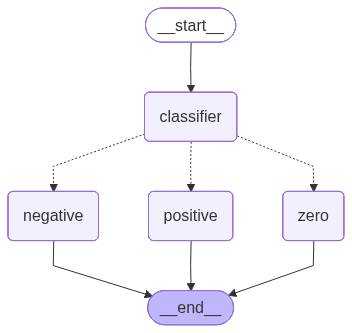

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## তিনটা ভিন্ন input দিয়ে পরীক্ষা করা

একই graph-এ তিনটা ভিন্ন সংখ্যা দিলে তিনটা ভিন্ন পথ নেবে!

In [13]:
test_numbers = [42, -7, 0]

for num in test_numbers:
    print(f"\n{'='*50}")
    print(f"Input: {num}")
    print('='*50)
    
    result = app.invoke({
        "number": num,
        "category": "",
        "message": ""
    })
    
    print(f"\n💬 চূড়ান্ত বার্তা: {result['message']}")


Input: 42
🔍 Classifier: 42 → category = 'positive'
🔀 Router সিদ্ধান্ত নিচ্ছে... category: 'positive'
✅ Positive node: message সেট করা হলো

💬 চূড়ান্ত বার্তা: 🌟 42 একটি ধনাত্মক সংখ্যা! এটি শূন্যের চেয়ে বড়।

Input: -7
🔍 Classifier: -7 → category = 'negative'
🔀 Router সিদ্ধান্ত নিচ্ছে... category: 'negative'
✅ Negative node: message সেট করা হলো

💬 চূড়ান্ত বার্তা: ❄️ -7 একটি ঋণাত্মক সংখ্যা! এটি শূন্যের চেয়ে ছোট।

Input: 0
🔍 Classifier: 0 → category = 'zero'
🔀 Router সিদ্ধান্ত নিচ্ছে... category: 'zero'
✅ Zero node: message সেট করা হলো

💬 চূড়ান্ত বার্তা: ⭕ 0 হলো শূন্য! না ধনাত্মক, না ঋণাত্মক।


## আরেকটু জটিল উদাহরণ: শব্দ বিশ্লেষক

এবার একটা শব্দ/sentence নিয়ে দেখব:
- যদি ৫ শব্দের কম হয় → `short_handler`
- যদি ৫-১০ শব্দ হয় → `medium_handler`
- যদি ১০ এর বেশি শব্দ হয় → `long_handler`

In [14]:
class TextAnalysisState(TypedDict):
    text: str
    word_count: int
    result: str


def counter_node(state: TextAnalysisState) -> TextAnalysisState:
    words = state['text'].split()
    state['word_count'] = len(words)
    print(f"📊 শব্দ গণনা: {state['word_count']} শব্দ")
    return state


def length_router(state: TextAnalysisState) -> Literal["short", "medium", "long"]:
    wc = state['word_count']
    if wc < 5:
        return "short"
    elif wc <= 10:
        return "medium"
    else:
        return "long"


def short_handler(state: TextAnalysisState) -> TextAnalysisState:
    state['result'] = f"✍️ সংক্ষিপ্ত text ({state['word_count']} শব্দ) — আরেকটু বিস্তারিত লিখুন!"
    return state

def medium_handler(state: TextAnalysisState) -> TextAnalysisState:
    state['result'] = f"👍 মাঝারি text ({state['word_count']} শব্দ) — ভালো দৈর্ঘ্য!"
    return state

def long_handler(state: TextAnalysisState) -> TextAnalysisState:
    state['result'] = f"📚 দীর্ঘ text ({state['word_count']} শব্দ) — হয়তো সংক্ষেপ করা যায়?"
    return state


# Graph
g2 = StateGraph(TextAnalysisState)
g2.add_node("counter", counter_node)
g2.add_node("short", short_handler)
g2.add_node("medium", medium_handler)
g2.add_node("long", long_handler)

g2.set_entry_point("counter")
g2.add_conditional_edges("counter", length_router, {"short": "short", "medium": "medium", "long": "long"})
g2.add_edge("short", END)
g2.add_edge("medium", END)
g2.add_edge("long", END)

app2 = g2.compile()

# Test
tests = [
    "হ্যালো",
    "আমি LangGraph শিখছি এবং এটা অনেক মজার",
    "LangGraph দিয়ে AI agent বানানো শেখা অনেক মজার কাজ এবং এটি দিয়ে জটিল workflow তৈরি করা যায় সহজেই"
]

for text in tests:
    r = app2.invoke({"text": text, "word_count": 0, "result": ""})
    print(f"Input: \"{text[:40]}...\"" if len(text) > 40 else f"Input: \"{text}\"")
    print(f"Output: {r['result']}\n")

📊 শব্দ গণনা: 1 শব্দ
Input: "হ্যালো"
Output: ✍️ সংক্ষিপ্ত text (1 শব্দ) — আরেকটু বিস্তারিত লিখুন!

📊 শব্দ গণনা: 7 শব্দ
Input: "আমি LangGraph শিখছি এবং এটা অনেক মজার"
Output: 👍 মাঝারি text (7 শব্দ) — ভালো দৈর্ঘ্য!

📊 শব্দ গণনা: 18 শব্দ
Input: "LangGraph দিয়ে AI agent বানানো শেখা অনে..."
Output: 📚 দীর্ঘ text (18 শব্দ) — হয়তো সংক্ষেপ করা যায়?



## সারসংক্ষেপ

এই notebook-এ শিখলাম:

- ✅ **Conditional Edges** — runtime-এ সিদ্ধান্ত নেওয়া যায় কোন পথে যাবে
- ✅ **Router Function** — state দেখে node-এর নাম return করে
- ✅ **add_conditional_edges()** — router-কে graph-এ যোগ করার পদ্ধতি
- ✅ **Mapping dictionary** — router-এর return value-কে node-এর নামে রূপান্তর

**পার্থক্য মনে রেখো:**
```
add_edge("A", "B")               → সবসময় A → B
add_conditional_edges("A", fn)   → fn(state) যা বলে সেদিকে যায়
```

**পরের notebook:** State Management — complex state, reducers, Annotated types! State-কে আরও শক্তিশালী করা! 🔧